# Stance Finetuning — Simplified Analysis

Compares base vs. QLoRA-finetuned models (individual datasets, pairs, all three) on
three test sets: **SemEval-2016**, **MT²-CSD**, **EZ-Stance (mixed)**. Covers
**Qwen3 1.7B**, **Qwen3 4B**, and **Phi-4-mini 3.8B**.

Three views, each as 3 separate charts (one per dataset) plus the underlying table:
1. Macro F1 by variant — line chart, one line per model.
2. Macro F1 by variant — heatmap, one per dataset.
3. Predicted class distribution (FAVOR/AGAINST/NONE) by variant, one per dataset,
   with the true (gold) share shown as a flat reference line per class.

## Setup & load

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import f1_score

pd.set_option("display.width", 120)

DATASETS = {
    "semeval2016_task6_testdata_gold": "semeval",
    "mtcsd_test":                      "mtcsd",
    "ezstance_test_mixed":             "ezstance",
}
CLASSES = ["FAVOR", "AGAINST", "NONE"]

# 3-class macro-F1 baselines, where a comparable number exists.
# NB: the official SemEval-2016 Task 6 metric is 2-class F_avg (FAVOR+AGAINST only) --
# 0.69 is that metric's best-system score, NOT comparable to 3-class macro F1. The
# 3-class number below is the local SVM_F3_tuned replication's macro F1 from
# svm_baseline.ipynb (its 2-class F_avg is 0.6907, i.e. the same ballpark as the 0.69
# figure people usually cite -- but its 3-class macro F1 is only 0.592).
# MTCSD's paper only reports a 2-class F_avg metric -- see F_AVG_BASELINES below instead.
BASELINES = {
    "semeval":  {"label": "SVM_F3_tuned, 3-class (svm_baseline.ipynb)", "macro_f1": 0.5924},
    "ezstance": {"label": "BART-MNLI (best supervised, ACL 2024)",      "macro_f1": 0.812},
    "mtcsd":    None,
}

# 2-class F_avg baselines (FAVOR+AGAINST F1 average, NONE excluded) -- the metric each
# dataset's own paper actually reports. Used by the MTCSD F_avg chart in Section 4.
F_AVG_BASELINES = {
    "semeval":  {"label": "SemEval-2016 best system (2016)", "f_avg": 0.69},
    "mtcsd":    {"label": "TTS (best, paper Table IX)",      "f_avg": 0.4267},
    "ezstance": None,
}

RESULTS_ROOTS = [
    Path("../data_out/finetune_qwen_1.7"),
    Path("../data_out/finetune_4b"),
    Path("../data_out/finetune_phi_mini"),
    Path("../data_out/finetune_8b_14b"),
]
RESULTS_ROOTS = [r for r in RESULTS_ROOTS if r.exists()]

FAMILY_DISPLAY = {"qwen3": "Qwen3", "phi4mini": "Phi-4-mini", "phi4": "Phi-4"}
MODEL_COLORS = {
    ("qwen3", 1.7): "#4C78A8",
    ("qwen3", 4.0): "#F58518",
    ("qwen3", 8.0): "#B279A2",
    ("phi4mini", 3.8): "#54A24B",
    ("phi4", 14.0): "#E45756",
}
MODEL_LINESTYLES = {
    ("qwen3", 1.7): "-",
    ("qwen3", 4.0): "--",
    ("qwen3", 8.0): (0, (5, 1, 1, 1)),
    ("phi4mini", 3.8): ":",
    ("phi4", 14.0): (0, (3, 1, 1, 1, 1, 1)),
}
# Ordered by model size, ascending -- mixes families deliberately so the "bigger model
# helps" trend is easy to read straight across a chart's legend.
PREFERRED_MODEL_ORDER = [("qwen3", 1.7), ("phi4mini", 3.8), ("qwen3", 4.0),
                           ("qwen3", 8.0), ("phi4", 14.0)]


def model_label(family, size):
    return f"{FAMILY_DISPLAY.get(family, family)} {size:g}B"


print("Result roots found:", [r.name for r in RESULTS_ROOTS])

Result roots found: ['finetune_qwen_1.7', 'finetune_4b', 'finetune_phi_mini', 'finetune_8b_14b']


In [2]:
def norm_label(x):
    """Uppercase and validate a stance label; anything unrecognised becomes NaN."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper()
    return s if s in CLASSES else np.nan


def parse_model_name(model_raw: str):
    """Return (family, size_b, is_finetune, trained_on) parsed from a run folder's model segment."""
    m = re.match(r"^Qwen3-([\d.]+)B$", model_raw)
    if m:
        return "qwen3", float(m.group(1)), False, ()
    m = re.match(r"^qwen3-([\d.]+)b-stance-matrix-([a-z-]+)-qlora$", model_raw)
    if m:
        return "qwen3", float(m.group(1)), True, tuple(sorted(m.group(2).split("-")))
    m = re.match(r"^phi-4-mini-instruct$", model_raw, re.IGNORECASE)
    if m:
        return "phi4mini", 3.8, False, ()
    m = re.match(r"^phi4mini-stance-matrix-([a-z-]+)-qlora$", model_raw)
    if m:
        return "phi4mini", 3.8, True, tuple(sorted(m.group(1).split("-")))
    m = re.match(r"^phi-4$", model_raw, re.IGNORECASE)
    if m:
        return "phi4", 14.0, False, ()
    m = re.match(r"^phi4-14b-stance-matrix-([a-z-]+)-qlora$", model_raw)
    if m:
        return "phi4", 14.0, True, tuple(sorted(m.group(1).split("-")))
    return None, None, None, None


def variant_label(is_finetune, trained_on):
    if not is_finetune:
        return "base"
    return "all3" if len(trained_on) == 3 else "+".join(trained_on)


def combo_sort_key(v):
    """Order variants: base, then single-dataset finetunes, then pairs, then all3."""
    if v == "base":
        return (0, v)
    if v == "all3":
        return (3, v)
    return (v.count("+") + 1, v)


def compute_metrics(csv_path):
    """Macro F1 plus predicted/gold class shares. Parse failures (missing or
    unparseable predictions) count as misses against recall, not dropped rows --
    they never match any class, so precision is unaffected but recall for the true
    class takes the hit. Dropping them instead silently inflates macro F1 whenever
    failures aren't uniform across classes."""
    df = pd.read_csv(csv_path)
    gold_all = df["original_stance"].map(norm_label)
    gold = gold_all[gold_all.notna()]
    pred = df["predicted_stance"].map(norm_label)[gold_all.notna()].fillna("PARSE_FAIL")

    per_class_f1 = f1_score(gold, pred, labels=CLASSES, average=None, zero_division=0)
    macro_f1 = float(per_class_f1.mean())
    f_avg = float((per_class_f1[0] + per_class_f1[1]) / 2)  # FAVOR, AGAINST only -- NONE excluded
    gold_pct = gold.value_counts(normalize=True).mul(100)
    pred_pct = pred.value_counts(normalize=True).mul(100)

    out = {"n": len(gold), "macro_f1": macro_f1, "f_avg": f_avg}
    for c in CLASSES:
        out[f"gold_{c.lower()}_pct"] = gold_pct.get(c, 0.0)
        out[f"pred_{c.lower()}_pct"] = pred_pct.get(c, 0.0)
    return out

In [3]:
records = []
for root in RESULTS_ROOTS:
    for dataset_dir, dataset_key in DATASETS.items():
        ds_path = root / dataset_dir
        if not ds_path.exists():
            continue
        for run_dir in sorted(ds_path.iterdir()):
            if not run_dir.is_dir():
                continue
            m = re.match(rf"GenAIStanceOneShot_\d+_{re.escape(dataset_dir)}_(.+)_equal_(.+)$", run_dir.name)
            if not m:
                continue
            model_raw, prompt = m.groups()
            family, size, is_finetune, trained_on = parse_model_name(model_raw)
            if size is None:
                continue
            csv_path = run_dir / "document_assignments.csv"
            if not csv_path.exists():
                continue
            records.append(dict(
                dataset=dataset_key, family=family, size=size,
                model_label=model_label(family, size),
                variant=variant_label(is_finetune, trained_on),
                root=root.name, csv_path=csv_path,
            ))

runs_df = pd.DataFrame(records)
runs_df = runs_df.drop_duplicates(subset=["dataset", "size", "variant"], keep="last").reset_index(drop=True)

metrics = runs_df["csv_path"].map(compute_metrics).apply(pd.Series)
results = pd.concat([runs_df.drop(columns="csv_path"), metrics], axis=1)

VARIANT_ORDER = sorted(results["variant"].unique(), key=combo_sort_key)
PREFERRED_MODEL_LABELS = [model_label(f, s) for f, s in PREFERRED_MODEL_ORDER]

print(f"Loaded {len(results)} runs · models: {sorted(results['model_label'].unique())}")
results[["dataset", "model_label", "variant", "n", "macro_f1"]].sort_values(["dataset", "model_label", "variant"])

Loaded 120 runs · models: ['Phi-4 14B', 'Phi-4-mini 3.8B', 'Qwen3 1.7B', 'Qwen3 4B', 'Qwen3 8B']


,dataset,model_label,variant,n,macro_f1
110,ezstance,Phi-4 14B,all3,7798.0,0.528025
105,ezstance,Phi-4 14B,base,7798.0,0.559250
106,ezstance,Phi-4 14B,ezstance,7798.0,0.545458
107,ezstance,Phi-4 14B,ezstance+mtcsd,7798.0,0.534360
109,ezstance,Phi-4 14B,ezstance+semeval,7798.0,0.527268
...,...,...,...,...,...
82,semeval,Qwen3 8B,ezstance+mtcsd,1249.0,0.540397
84,semeval,Qwen3 8B,ezstance+semeval,1249.0,0.578693
83,semeval,Qwen3 8B,mtcsd,1249.0,0.551569
86,semeval,Qwen3 8B,mtcsd+semeval,1249.0,0.566049


## 1 · Macro F1 by variant — line charts

One chart per dataset, one line per model, one dot per variant.

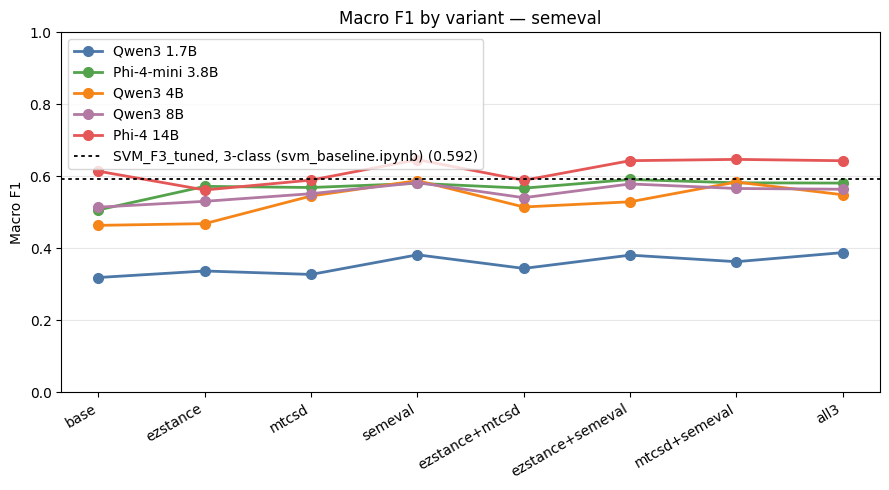

--- semeval ---
model_label       Qwen3 1.7B  Phi-4-mini 3.8B  Qwen3 4B  Qwen3 8B  Phi-4 14B
variant                                                                     
base                  0.3186           0.5065    0.4636    0.5141     0.6140
ezstance              0.3367           0.5719    0.4684    0.5304     0.5619
mtcsd                 0.3271           0.5688    0.5452    0.5516     0.5894
semeval               0.3817           0.5803    0.5880    0.5824     0.6462
ezstance+mtcsd        0.3439           0.5669    0.5146    0.5404     0.5888
ezstance+semeval      0.3808           0.5911    0.5290    0.5787     0.6433
mtcsd+semeval         0.3626           0.5818    0.5840    0.5660     0.6469
all3                  0.3879           0.5811    0.5486    0.5639     0.6432



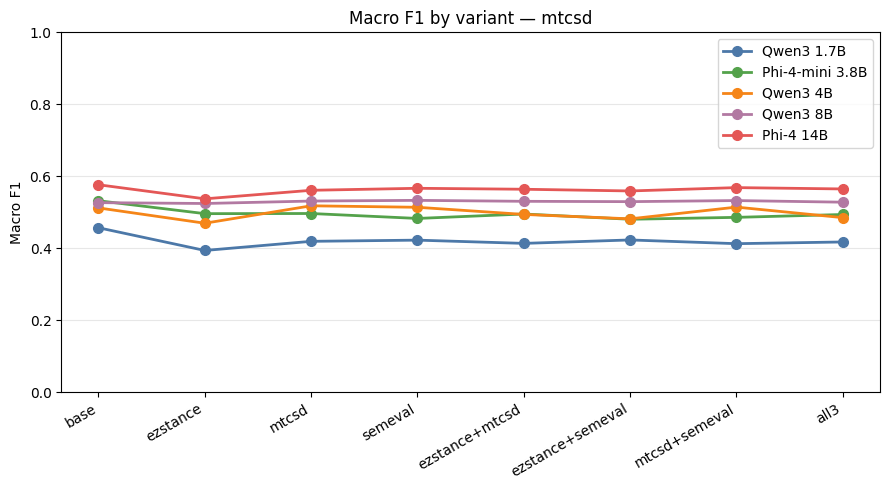

--- mtcsd ---
model_label       Qwen3 1.7B  Phi-4-mini 3.8B  Qwen3 4B  Qwen3 8B  Phi-4 14B
variant                                                                     
base                  0.4569           0.5320    0.5120    0.5267     0.5764
ezstance              0.3938           0.4961    0.4695    0.5243     0.5373
mtcsd                 0.4192           0.4965    0.5179    0.5311     0.5610
semeval               0.4225           0.4828    0.5138    0.5330     0.5666
ezstance+mtcsd        0.4135           0.4951    0.4939    0.5304     0.5639
ezstance+semeval      0.4230           0.4805    0.4816    0.5294     0.5592
mtcsd+semeval         0.4126           0.4858    0.5143    0.5324     0.5685
all3                  0.4174           0.4937    0.4850    0.5280     0.5647



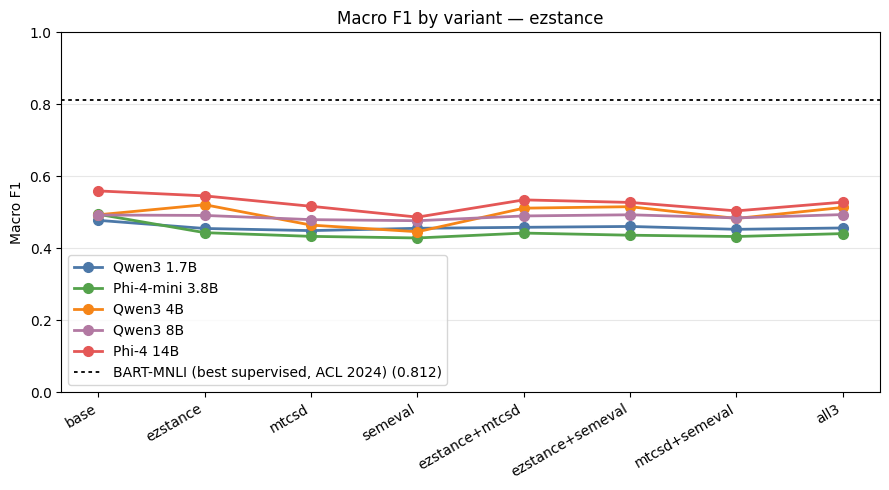

--- ezstance ---
model_label       Qwen3 1.7B  Phi-4-mini 3.8B  Qwen3 4B  Qwen3 8B  Phi-4 14B
variant                                                                     
base                  0.4775           0.4942    0.4929    0.4923     0.5592
ezstance              0.4549           0.4432    0.5209    0.4911     0.5455
mtcsd                 0.4490           0.4330    0.4642    0.4795     0.5165
semeval               0.4554           0.4285    0.4458    0.4765     0.4865
ezstance+mtcsd        0.4581           0.4421    0.5113    0.4897     0.5344
ezstance+semeval      0.4605           0.4362    0.5154    0.4930     0.5273
mtcsd+semeval         0.4525           0.4326    0.4827    0.4842     0.5038
all3                  0.4563           0.4407    0.5133    0.4935     0.5280



In [4]:
f1_tables = {}
for dataset_key in DATASETS.values():
    sub = results[results["dataset"] == dataset_key]
    wide = sub.pivot_table(index="variant", columns="model_label", values="macro_f1")
    wide = wide.reindex(VARIANT_ORDER)
    wide = wide[[c for c in PREFERRED_MODEL_LABELS if c in wide.columns]]
    f1_tables[dataset_key] = wide

    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(wide.index))
    for f, s in PREFERRED_MODEL_ORDER:
        col = model_label(f, s)
        if col not in wide.columns:
            continue
        ax.plot(x, wide[col], marker="o", markersize=7, linewidth=2,
                 color=MODEL_COLORS[(f, s)], label=col)
    ax.set_xticks(x)
    ax.set_xticklabels(wide.index, rotation=30, ha="right")
    ax.set_ylabel("Macro F1")
    ax.set_ylim(0, 1)
    bl = BASELINES.get(dataset_key)
    if bl is not None:
        ax.axhline(bl["macro_f1"], color="black", linestyle=(0, (2, 2)), linewidth=1.3,
                    label=f"{bl['label']} ({bl['macro_f1']:.3f})")
    ax.set_title(f"Macro F1 by variant \u2014 {dataset_key}")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"--- {dataset_key} ---")
    print(wide.round(4))
    print()

## 2 · Macro F1 by variant — heatmaps

Same data as Section 1, as a heatmap: rows = variant, columns = model.

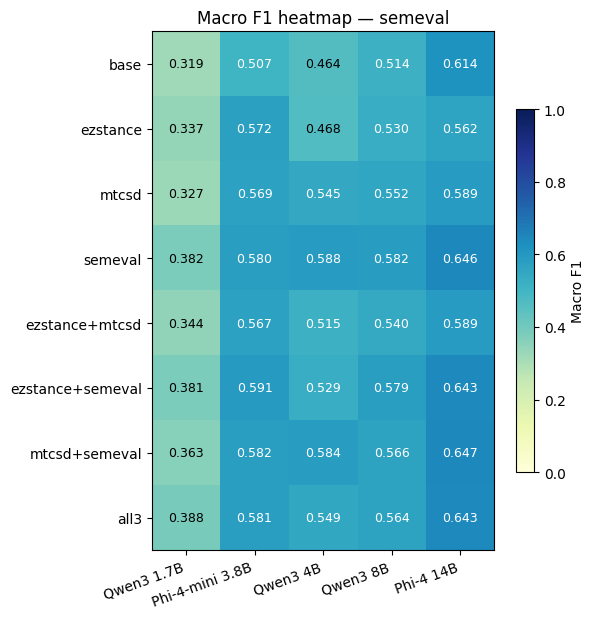

--- semeval ---
model_label       Qwen3 1.7B  Phi-4-mini 3.8B  Qwen3 4B  Qwen3 8B  Phi-4 14B
variant                                                                     
base                  0.3186           0.5065    0.4636    0.5141     0.6140
ezstance              0.3367           0.5719    0.4684    0.5304     0.5619
mtcsd                 0.3271           0.5688    0.5452    0.5516     0.5894
semeval               0.3817           0.5803    0.5880    0.5824     0.6462
ezstance+mtcsd        0.3439           0.5669    0.5146    0.5404     0.5888
ezstance+semeval      0.3808           0.5911    0.5290    0.5787     0.6433
mtcsd+semeval         0.3626           0.5818    0.5840    0.5660     0.6469
all3                  0.3879           0.5811    0.5486    0.5639     0.6432



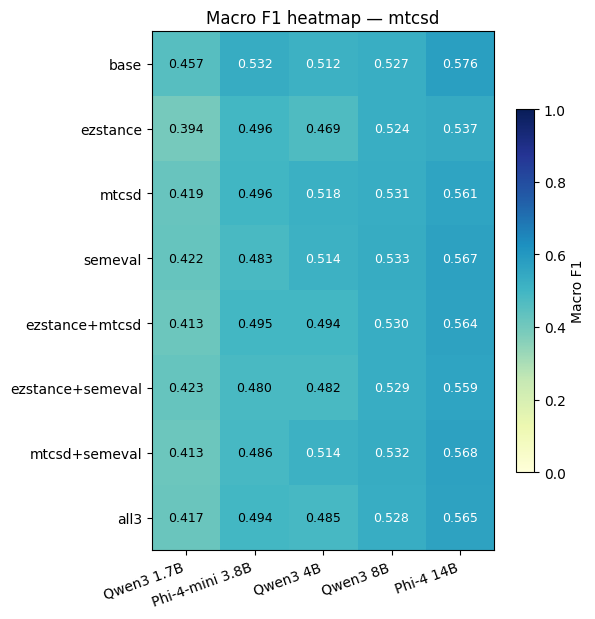

--- mtcsd ---
model_label       Qwen3 1.7B  Phi-4-mini 3.8B  Qwen3 4B  Qwen3 8B  Phi-4 14B
variant                                                                     
base                  0.4569           0.5320    0.5120    0.5267     0.5764
ezstance              0.3938           0.4961    0.4695    0.5243     0.5373
mtcsd                 0.4192           0.4965    0.5179    0.5311     0.5610
semeval               0.4225           0.4828    0.5138    0.5330     0.5666
ezstance+mtcsd        0.4135           0.4951    0.4939    0.5304     0.5639
ezstance+semeval      0.4230           0.4805    0.4816    0.5294     0.5592
mtcsd+semeval         0.4126           0.4858    0.5143    0.5324     0.5685
all3                  0.4174           0.4937    0.4850    0.5280     0.5647



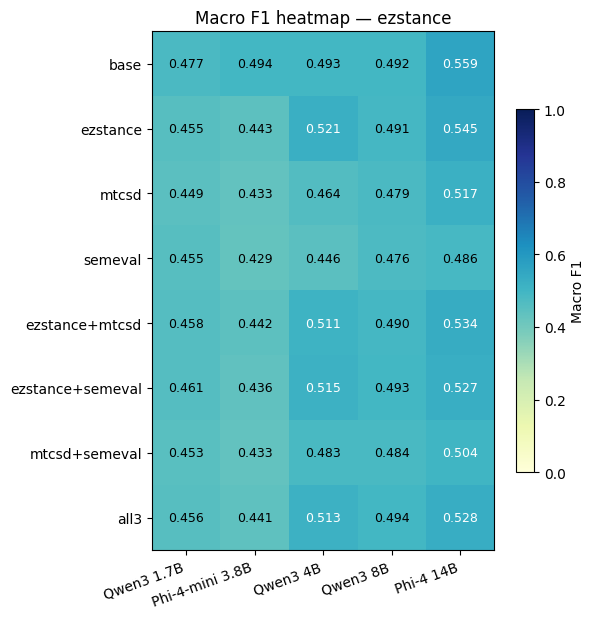

--- ezstance ---
model_label       Qwen3 1.7B  Phi-4-mini 3.8B  Qwen3 4B  Qwen3 8B  Phi-4 14B
variant                                                                     
base                  0.4775           0.4942    0.4929    0.4923     0.5592
ezstance              0.4549           0.4432    0.5209    0.4911     0.5455
mtcsd                 0.4490           0.4330    0.4642    0.4795     0.5165
semeval               0.4554           0.4285    0.4458    0.4765     0.4865
ezstance+mtcsd        0.4581           0.4421    0.5113    0.4897     0.5344
ezstance+semeval      0.4605           0.4362    0.5154    0.4930     0.5273
mtcsd+semeval         0.4525           0.4326    0.4827    0.4842     0.5038
all3                  0.4563           0.4407    0.5133    0.4935     0.5280



In [5]:
for dataset_key, wide in f1_tables.items():
    fig, ax = plt.subplots(figsize=(6, 0.6 * len(wide) + 1.5))
    im = ax.imshow(wide.values.astype(float), cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(wide.columns)))
    ax.set_xticklabels(wide.columns, rotation=20, ha="right")
    ax.set_yticks(range(len(wide.index)))
    ax.set_yticklabels(wide.index)
    for i in range(wide.shape[0]):
        for j in range(wide.shape[1]):
            val = wide.values[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9,
                         color="white" if val > 0.5 else "black")
    ax.set_title(f"Macro F1 heatmap \u2014 {dataset_key}")
    fig.colorbar(im, ax=ax, shrink=0.7, label="Macro F1")
    plt.tight_layout()
    plt.show()

    print(f"--- {dataset_key} ---")
    print(wide.round(4))
    print()

## 3 · Predicted class distribution by variant

One chart per dataset. 3 colors = class (FAVOR/AGAINST/NONE), 1 line style per model
(see legend). Thin dotted flat lines = the true (gold) class share for that dataset --
the gap between a colored line and its matching flat line is how far off that
model/variant is from the truth.

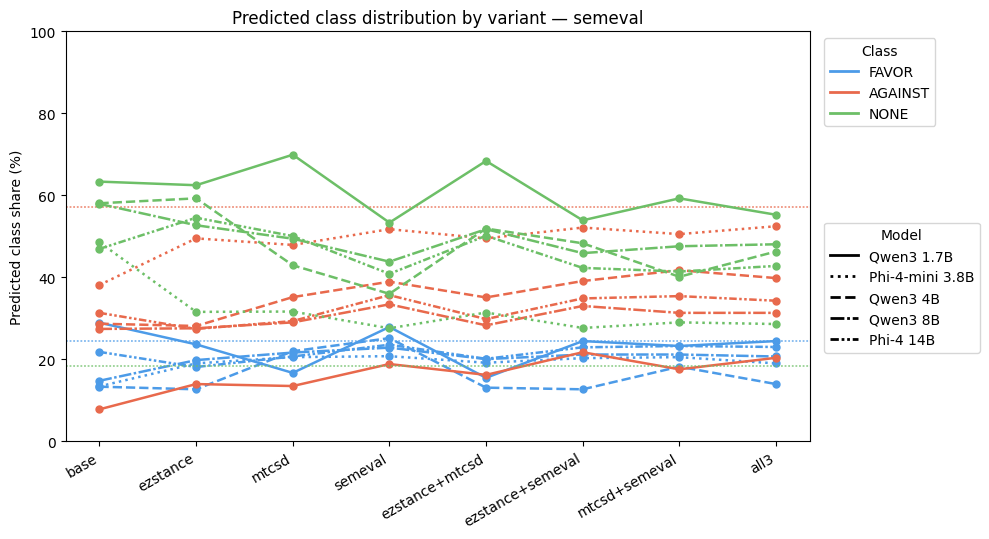

--- semeval: predicted class % by variant & model (gold share in parentheses) ---
FAVOR (gold = 24.3%):
model_label       Qwen3 1.7B  Phi-4-mini 3.8B  Qwen3 4B  Qwen3 8B  Phi-4 14B
variant                                                                     
base                    28.9             13.4      13.3      14.7       21.8
ezstance                23.6             19.0      12.7      19.8       18.1
mtcsd                   16.7             20.5      21.9      21.6       20.7
semeval                 27.9             20.7      25.1      22.8       23.5
ezstance+mtcsd          15.5             19.1      13.1      20.0       20.1
ezstance+semeval        24.4             20.3      12.7      21.1       22.9
mtcsd+semeval           23.2             20.5      18.2      21.1       23.2
all3                    24.4             19.0      13.9      20.7       23.0
AGAINST (gold = 57.2%):
model_label       Qwen3 1.7B  Phi-4-mini 3.8B  Qwen3 4B  Qwen3 8B  Phi-4 14B
variant                  

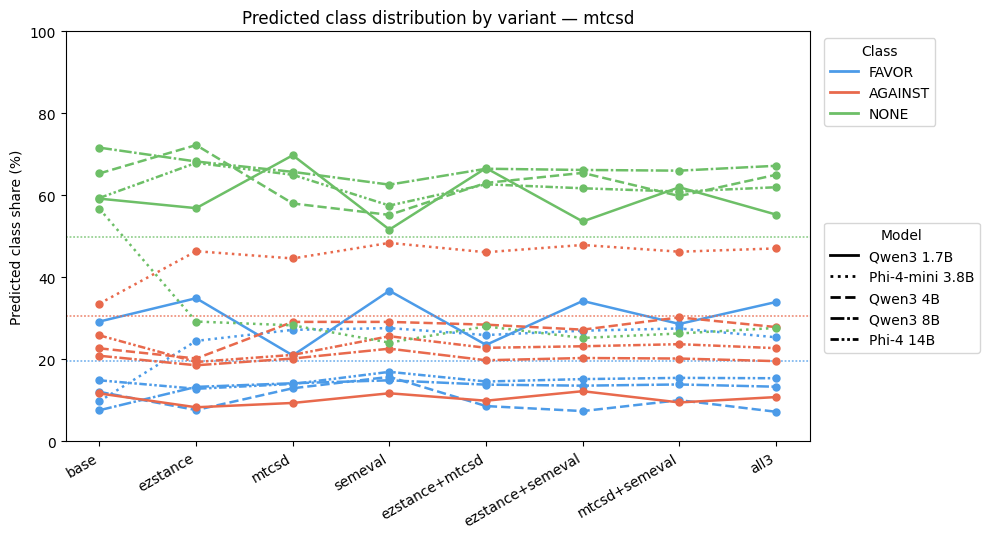

--- mtcsd: predicted class % by variant & model (gold share in parentheses) ---
FAVOR (gold = 19.7%):
model_label       Qwen3 1.7B  Phi-4-mini 3.8B  Qwen3 4B  Qwen3 8B  Phi-4 14B
variant                                                                     
base                    29.2              9.7      12.0       7.5       14.8
ezstance                34.9             24.5       7.6      13.2       12.8
mtcsd                   20.9             27.2      12.9      14.1       14.0
semeval                 36.7             27.6      15.7      14.8       16.9
ezstance+mtcsd          23.5             25.9       8.6      13.8       14.6
ezstance+semeval        34.2             27.0       7.3      13.5       15.1
mtcsd+semeval           28.6             27.5      10.0      13.8       15.4
all3                    34.0             25.3       7.2      13.3       15.4
AGAINST (gold = 30.5%):
model_label       Qwen3 1.7B  Phi-4-mini 3.8B  Qwen3 4B  Qwen3 8B  Phi-4 14B
variant                    

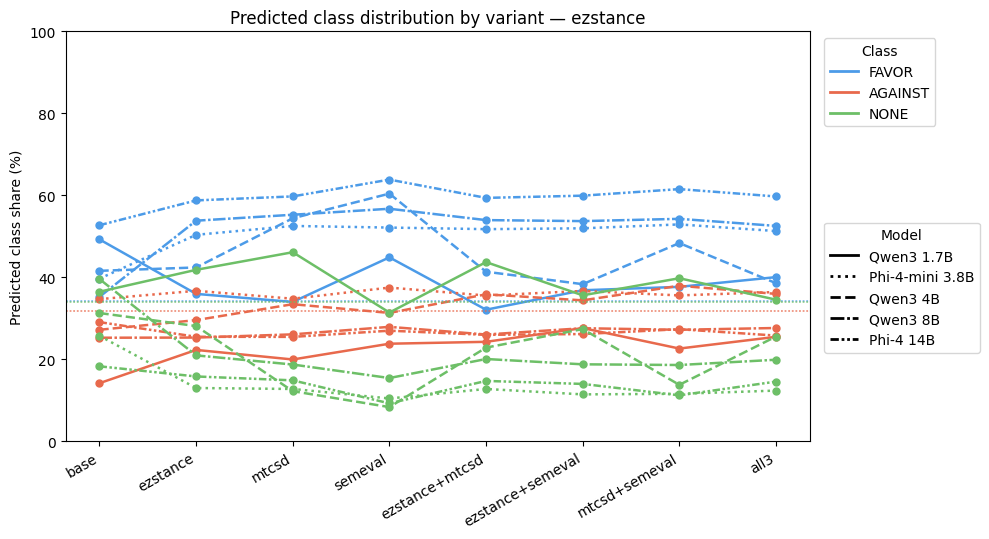

--- ezstance: predicted class % by variant & model (gold share in parentheses) ---
FAVOR (gold = 34.2%):
model_label       Qwen3 1.7B  Phi-4-mini 3.8B  Qwen3 4B  Qwen3 8B  Phi-4 14B
variant                                                                     
base                    49.2             39.7      41.6      35.2       52.7
ezstance                35.9             50.3      42.4      53.8       58.7
mtcsd                   34.0             52.5      54.4      55.2       59.7
semeval                 44.8             52.1      60.4      56.7       63.8
ezstance+mtcsd          32.1             51.7      41.3      53.9       59.4
ezstance+semeval        36.8             51.9      38.3      53.7       59.9
mtcsd+semeval           37.7             52.9      48.3      54.2       61.5
all3                    40.0             51.3      38.5      52.5       59.7
AGAINST (gold = 31.8%):
model_label       Qwen3 1.7B  Phi-4-mini 3.8B  Qwen3 4B  Qwen3 8B  Phi-4 14B
variant                 

In [6]:
CLASS_COLORS = {"FAVOR": "#4C9BE8", "AGAINST": "#E8694C", "NONE": "#6DBF67"}
pred_tables = {}

for dataset_key in DATASETS.values():
    sub = results[results["dataset"] == dataset_key]
    fig, ax = plt.subplots(figsize=(10, 5.5))
    x = np.arange(len(VARIANT_ORDER))

    for cls in CLASSES:
        col = f"pred_{cls.lower()}_pct"
        wide = sub.pivot_table(index="variant", columns="model_label", values=col)
        wide = wide.reindex(VARIANT_ORDER)
        wide = wide[[c for c in PREFERRED_MODEL_LABELS if c in wide.columns]]
        pred_tables[(dataset_key, cls)] = wide
        for f, s in PREFERRED_MODEL_ORDER:
            mcol = model_label(f, s)
            if mcol not in wide.columns:
                continue
            ax.plot(x, wide[mcol], marker="o", markersize=5, linewidth=1.8,
                     color=CLASS_COLORS[cls], linestyle=MODEL_LINESTYLES[(f, s)])
        gold_pct = sub[f"gold_{cls.lower()}_pct"].iloc[0]
        ax.axhline(gold_pct, color=CLASS_COLORS[cls], linestyle=(0, (1, 1)), linewidth=1.3, alpha=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels(VARIANT_ORDER, rotation=30, ha="right")
    ax.set_ylabel("Predicted class share (%)")
    ax.set_ylim(0, 100)
    ax.set_title(f"Predicted class distribution by variant \u2014 {dataset_key}")

    class_handles = [Line2D([0], [0], color=CLASS_COLORS[c], lw=2, label=c) for c in CLASSES]
    model_handles = [Line2D([0], [0], color="black", lw=2, linestyle=MODEL_LINESTYLES[fs],
                              label=model_label(*fs))
                      for fs in PREFERRED_MODEL_ORDER if model_label(*fs) in sub["model_label"].unique()]
    leg1 = ax.legend(handles=class_handles, title="Class", loc="upper left", bbox_to_anchor=(1.01, 1.0))
    ax.add_artist(leg1)
    ax.legend(handles=model_handles, title="Model", loc="upper left", bbox_to_anchor=(1.01, 0.55))
    plt.tight_layout()
    plt.show()

    print(f"--- {dataset_key}: predicted class % by variant & model (gold share in parentheses) ---")
    for cls in CLASSES:
        gold_pct = sub[f"gold_{cls.lower()}_pct"].iloc[0]
        print(f"{cls} (gold = {gold_pct:.1f}%):")
        print(pred_tables[(dataset_key, cls)].round(1))
    print()

## 4 · MTCSD — 2-class F_avg (matches the paper's own metric)

The MT²-CSD paper's Table IX baselines (TTS, KPT, BERT) are reported as 2-class
F_avg = (F1_FAVOR + F1_AGAINST) / 2, with NONE excluded -- not comparable to the
3-class macro F1 used in Sections 1-3. This chart uses that same 2-class metric for
everything (base, every finetuned variant, every model) plus the paper's TTS
baseline, so there's finally an apples-to-apples comparison for MTCSD.

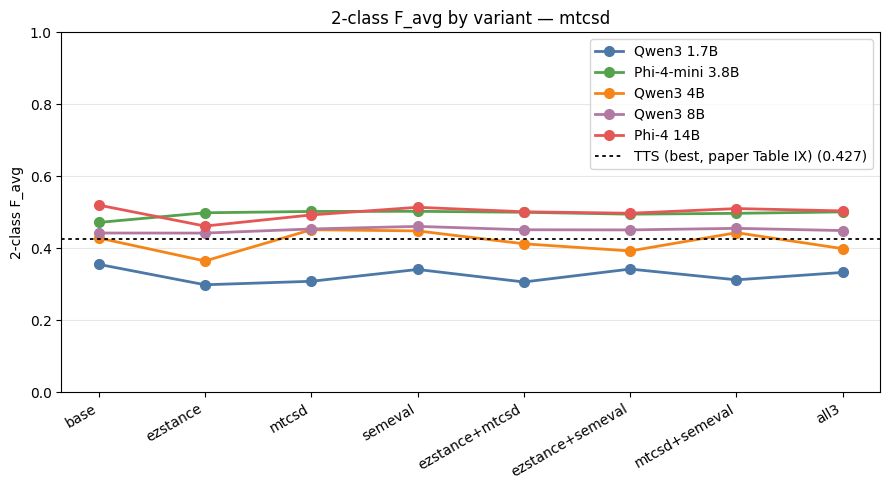

--- mtcsd: 2-class F_avg ---
model_label       Qwen3 1.7B  Phi-4-mini 3.8B  Qwen3 4B  Qwen3 8B  Phi-4 14B
variant                                                                     
base                  0.3553           0.4716    0.4285    0.4423     0.5199
ezstance              0.2984           0.4985    0.3645    0.4421     0.4616
mtcsd                 0.3081           0.5022    0.4514    0.4535     0.4925
semeval               0.3410           0.5026    0.4482    0.4607     0.5138
ezstance+mtcsd        0.3062           0.4999    0.4123    0.4513     0.5013
ezstance+semeval      0.3421           0.4946    0.3924    0.4509     0.4972
mtcsd+semeval         0.3122           0.4970    0.4432    0.4553     0.5102
all3                  0.3328           0.5010    0.3987    0.4491     0.5037


In [7]:
dataset_key = "mtcsd"
sub = results[results["dataset"] == dataset_key]
wide_favg = sub.pivot_table(index="variant", columns="model_label", values="f_avg")
wide_favg = wide_favg.reindex(VARIANT_ORDER)
wide_favg = wide_favg[[c for c in PREFERRED_MODEL_LABELS if c in wide_favg.columns]]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(wide_favg.index))
for f, s in PREFERRED_MODEL_ORDER:
    col = model_label(f, s)
    if col not in wide_favg.columns:
        continue
    ax.plot(x, wide_favg[col], marker="o", markersize=7, linewidth=2,
             color=MODEL_COLORS[(f, s)], label=col)

bl = F_AVG_BASELINES.get(dataset_key)
if bl is not None:
    ax.axhline(bl["f_avg"], color="black", linestyle=(0, (2, 2)), linewidth=1.3,
                label=f"{bl['label']} ({bl['f_avg']:.3f})")

ax.set_xticks(x)
ax.set_xticklabels(wide_favg.index, rotation=30, ha="right")
ax.set_ylabel("2-class F_avg")
ax.set_ylim(0, 1)
ax.set_title(f"2-class F_avg by variant \u2014 {dataset_key}")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"--- {dataset_key}: 2-class F_avg ---")
print(wide_favg.round(4))